# FIFA World Cup Predictor

## Version 5 - Class-Balanced Model

### Objective

Version 4's model barely predicts draws:

| Outcome | Recall |
|---------|--------|
| Away Win | 0.53 |
| **Draw** | **0.12** |
| Home Win | 0.79 |

This notebook runs a controlled experiment: does telling the model to care more about rare classes improve draw prediction?

We train **two models** with the exact same features and the exact same chronological 80/20 split:

1. **Baseline**: `RandomForestClassifier(n_estimators=200, random_state=42)`
2. **Class-balanced**: `RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')`

The only difference is `class_weight='balanced'`. No new features, no other tuning.

In [1]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model Training
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)

In [2]:
df = pd.read_csv("../data/raw/results.csv")

print(df.shape)
df.head()

(49477, 9)


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [3]:
df.isnull().sum()

date           0
home_team      0
away_team      0
home_score    64
away_score    64
tournament     0
city           0
country        0
neutral        0
dtype: int64

In [4]:
# Drop the 64 future World Cup fixtures that have no score yet
df = df.dropna(subset=['home_score', 'away_score']).reset_index(drop=True)

print(df.shape)

df.isnull().sum()

(49413, 9)


date          0
home_team     0
away_team     0
home_score    0
away_score    0
tournament    0
city          0
country       0
neutral       0
dtype: int64

In [5]:
def get_result(row):
    if row['home_score'] > row['away_score']:
        return 2      # Home Win
    elif row['home_score'] < row['away_score']:
        return 0      # Away Win
    else:
        return 1      # Draw

In [6]:
df['result'] = df.apply(get_result, axis=1)

df['result'].value_counts()

result
2    24216
0    13961
1    11236
Name: count, dtype: int64

In [7]:
df['neutral_encoded'] = df['neutral'].astype(int)
df[['neutral', 'neutral_encoded']].head()

,neutral,neutral_encoded
0,False,0
1,False,0
2,False,0
3,False,0
4,False,0


# Step 1 - Build Elo Ratings (unchanged from Versions 3 and 4)

Exactly the same Elo code as before:

- Every team starts at 1500.
- After each match, both ratings are updated (K-factor = 20).
- We save each team's rating **BEFORE** the match, so the model never sees the future.

The dataframe stays sorted by date - this matters for the chronological split.

In [8]:
teams = pd.concat([
    df['home_team'],
    df['away_team']
    ]).unique()

elo_rating = {
    team:1500
    for team in teams
    }

In [9]:
def expected_score(rating_a, rating_b):
    return 1 / (1 + 10 ** ((rating_b - rating_a) / 400))

def update_elo(rating, expected, actual, k=20):
    return rating + k * (actual - expected)

In [10]:
home_elos = []
away_elos = []

In [11]:
# Work through the matches in chronological order
df['date'] = pd.to_datetime(df['date'])

df = df.sort_values('date').reset_index(drop=True)

In [12]:
for _, row in df.iterrows():

    home_team = row['home_team']
    away_team = row['away_team']

    home_elo = elo_rating[home_team]
    away_elo = elo_rating[away_team]

    # Save Elo BEFORE the match
    home_elos.append(home_elo)
    away_elos.append(away_elo)

    # Expected results
    expected_home = expected_score(home_elo, away_elo)
    expected_away = expected_score(away_elo, home_elo)

    # Actual result
    if row['result'] == 2:      # Home win
        actual_home = 1
        actual_away = 0

    elif row['result'] == 0:    # Away win
        actual_home = 0
        actual_away = 1

    else:                       # Draw
        actual_home = 0.5
        actual_away = 0.5

    # Update ratings
    elo_rating[home_team] = update_elo(
        home_elo,
        expected_home,
        actual_home
    )

    elo_rating[away_team] = update_elo(
        away_elo,
        expected_away,
        actual_away
    )

In [13]:
df['home_elo'] = home_elos
df['away_elo'] = away_elos

df['elo_difference'] = df['home_elo'] - df['away_elo']

# Step 2 - Build Recent Form Features (unchanged from Versions 3 and 4)

Exactly the same recent-form code as before:

- Form = average points from a team's last 5 matches (Win = 1.0, Draw = 0.5, Loss = 0.0).
- Form is computed from matches **BEFORE** the current match (no leakage).

In [14]:
# How many recent matches to look back
FORM_WINDOW = 5

# Each team's recent results, stored as points (oldest first)
team_form_history = {team: [] for team in teams}

home_forms = []
away_forms = []

for _, row in df.iterrows():

    home_team = row['home_team']
    away_team = row['away_team']

    # 1) Form from matches BEFORE this one (no leakage!)
    home_history = team_form_history[home_team]
    away_history = team_form_history[away_team]

    home_form = np.mean(home_history) if len(home_history) > 0 else 0.0
    away_form = np.mean(away_history) if len(away_history) > 0 else 0.0

    # Save form BEFORE updating the histories
    home_forms.append(home_form)
    away_forms.append(away_form)

    # 2) Points for the current match
    if row['result'] == 2:      # Home win
        home_points = 1.0
        away_points = 0.0

    elif row['result'] == 0:    # Away win
        home_points = 0.0
        away_points = 1.0

    else:                       # Draw
        home_points = 0.5
        away_points = 0.5

    # 3) NOW update each team's history with the current result
    home_history.append(home_points)
    away_history.append(away_points)

    # Keep only the last 5 matches
    if len(home_history) > FORM_WINDOW:
        home_history.pop(0)
    if len(away_history) > FORM_WINDOW:
        away_history.pop(0)

In [15]:
df['home_form'] = home_forms
df['away_form'] = away_forms

df[['date', 'home_team', 'away_team', 'home_form', 'away_form', 'result']].head(10)

,date,home_team,away_team,home_form,away_form,result
0,1872-11-30,Scotland,England,0.00,0.00,1
1,1873-03-08,England,Scotland,0.50,0.50,2
2,1874-03-07,Scotland,England,0.25,0.75,2
3,1875-03-06,England,Scotland,0.50,0.50,1
4,1876-03-04,Scotland,England,0.50,0.50,2
5,1876-03-25,Scotland,Wales,0.60,0.00,2
6,1877-03-03,England,Scotland,0.40,0.70,0
7,1877-03-05,Wales,Scotland,0.00,0.90,0
8,1878-03-02,Scotland,England,0.90,0.30,2
9,1878-03-23,Scotland,Wales,1.00,0.00,2


In [16]:
# Quick sanity checks (from Versions 3 and 4)
print("W W D L W =", np.mean([1.0, 1.0, 0.5, 0.0, 1.0]))
print("Missing form values:", df[['home_form', 'away_form']].isnull().sum().sum())

W W D L W = 0.7
Missing form values: 0


# Step 3 - Chronological Train/Test Split

Same as Version 4: the dataframe is already sorted by date, so we take the **oldest 80%** as training and the **newest 20%** as testing.

```text
Older historical matches -> Training data
Newer historical matches -> Test data
```

In [17]:
# Split the chronological dataframe: oldest 80% -> train, newest 20% -> test
split_index = int(len(df) * 0.8)

train = df.iloc[:split_index]
test = df.iloc[split_index:]

print("Training matches:    ", len(train))
print("Testing matches:     ", len(test))
print()
print("Training period:     ", train['date'].min().date(), "to", train['date'].max().date())
print("Testing period:      ", test['date'].min().date(), "to", test['date'].max().date())

Training matches:     39530
Testing matches:      9883

Training period:      1872-11-30 to 2016-03-25
Testing period:       2016-03-25 to 2026-06-13


In [18]:
feature_cols = [
    'home_elo',
    'away_elo',
    'elo_difference',
    'home_form',
    'away_form',
    'neutral_encoded'
]

X_train = train[feature_cols]
y_train = train['result']

X_test = test[feature_cols]
y_test = test['result']

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print()
print("Test set outcome counts (the class imbalance):")
print(y_test.value_counts())

X_train shape: (39530, 6)
X_test shape:  (9883, 6)

Test set outcome counts (the class imbalance):
result
2    4708
0    2871
1    2304
Name: count, dtype: int64


# Step 4 - The Draw Problem: Class Imbalance

### What is class imbalance?

The three outcomes are **not** equally common. In the test set you can see it directly:

```text
Home Win: ~48%   (the common class)
Away Win: ~29%
Draw:     ~23%   (the rare class)
```

When classes are imbalanced, a model can look "good" by mostly predicting the common class
(Home Win) and ignoring the rare class (Draw) - which is exactly what Version 4 did.

### What does `class_weight='balanced'` do?

By default the Random Forest counts an error on any match the same. Because Home Wins are the
most common, the model is rewarded for predicting them often and rarely bothers to predict draws.

`class_weight='balanced'` automatically gives rare classes a **bigger penalty** when they are
wrong, and common classes a smaller penalty. Scikit-learn computes the weight of each class as
inversely proportional to how often it appears:

```text
weight = total samples / (number of classes * class size)
```

Fewer matches of a class -> higher weight -> the model tries harder to get that class right.

### Why accuracy alone is not enough

Imagine a model that predicted **Home Win for every match**. It would be right about 48% of the
time - yet it would never predict a single draw or away win. The accuracy looks "fine", but the
model is useless for real prediction.

That is why we compare per-class **precision**, **recall** and **F1**:

- **Recall**: of the matches that were actually draws, how many did we catch?
- **Precision**: when the model predicts a draw, how often is it right?
- **F1**: a balance of the two.

If class weighting improves draw recall - even at a small cost to accuracy - it may be the
better model for real matches.

In [19]:
# Model 1 - Baseline (same as Version 4)
model_baseline = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
model_baseline.fit(X_train, y_train)

# Model 2 - Class-balanced (the only change)
model_balanced = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)
model_balanced.fit(X_train, y_train)

print("Baseline model trained.")
print("Class-balanced model trained.")

Baseline model trained.
Class-balanced model trained.


# Step 5 - Compare the Two Models

Both models are evaluated on the exact same test set (the newest 20% of matches, 2016-2026).

In [20]:
pred_baseline = model_baseline.predict(X_test)
pred_balanced = model_balanced.predict(X_test)

acc_baseline = accuracy_score(y_test, pred_baseline)
acc_balanced = accuracy_score(y_test, pred_balanced)

print("Baseline accuracy:      ", acc_baseline)
print("Class-balanced accuracy:", acc_balanced)

Baseline accuracy:       0.5591419609430335
Class-balanced accuracy: 0.5336436304765759


In [21]:
print("===== BASELINE MODEL =====")
print(classification_report(y_test, pred_baseline))

===== BASELINE MODEL =====
              precision    recall  f1-score   support

           0       0.54      0.53      0.54      2871
           1       0.28      0.12      0.17      2304
           2       0.61      0.79      0.69      4708

    accuracy                           0.56      9883
   macro avg       0.48      0.48      0.46      9883
weighted avg       0.51      0.56      0.52      9883



In [22]:
print("===== CLASS-BALANCED MODEL =====")
print(classification_report(y_test, pred_balanced))

===== CLASS-BALANCED MODEL =====
              precision    recall  f1-score   support

           0       0.51      0.56      0.54      2871
           1       0.27      0.22      0.24      2304
           2       0.65      0.67      0.66      4708

    accuracy                           0.53      9883
   macro avg       0.48      0.48      0.48      9883
weighted avg       0.52      0.53      0.53      9883



# Step 5b - Confusion Matrices Side by Side

Rows = actual result, Columns = predicted result. The diagonal is where the model is correct.
Notice how many more draws (middle column) the balanced model catches.

Baseline confusion matrix:
[[1526  320 1025]
 [ 677  271 1356]
 [ 603  376 3729]]

Class-balanced confusion matrix:
[[1613  569  689]
 [ 763  504 1037]
 [ 759  792 3157]]


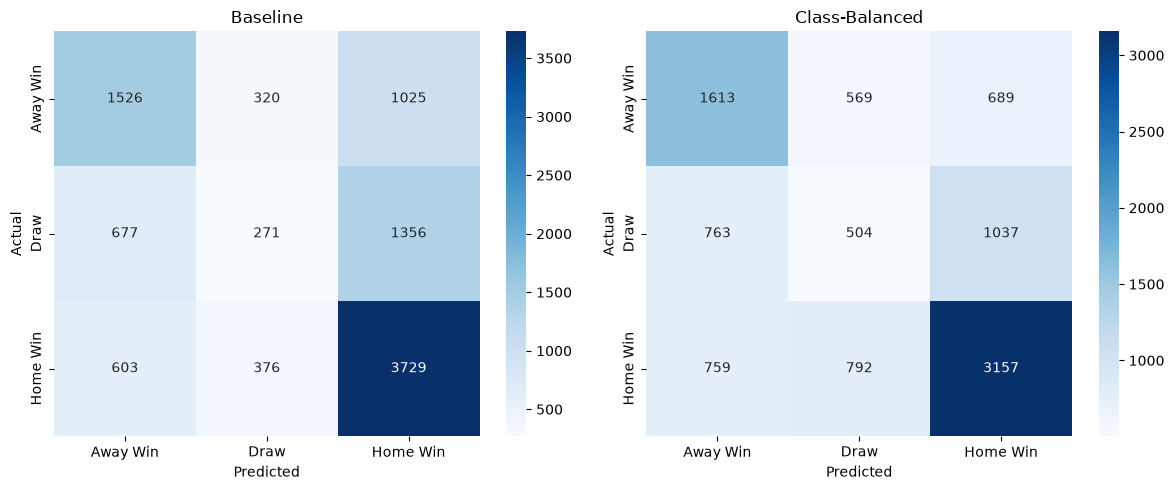

In [23]:
%matplotlib inline

cm_baseline = confusion_matrix(y_test, pred_baseline)
cm_balanced = confusion_matrix(y_test, pred_balanced)

print("Baseline confusion matrix:")
print(cm_baseline)
print()
print("Class-balanced confusion matrix:")
print(cm_balanced)

labels_cm = ['Away Win', 'Draw', 'Home Win']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_cm, yticklabels=labels_cm, ax=axes[0])
axes[0].set_title('Baseline')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_balanced, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_cm, yticklabels=labels_cm, ax=axes[1])
axes[1].set_title('Class-Balanced')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Step 5c - Per-Class Precision, Recall and F1

This table makes the trade-off easy to see for each class.

In [24]:
labels = [0, 1, 2]
class_names = ['Away Win', 'Draw', 'Home Win']

p_base, r_base, f_base, _ = precision_recall_fscore_support(
    y_test, pred_baseline, labels=labels, average=None
)
p_bal, r_bal, f_bal, _ = precision_recall_fscore_support(
    y_test, pred_balanced, labels=labels, average=None
)

comparison = pd.DataFrame({
    'Class': class_names,
    'Baseline Precision': p_base,
    'Balanced Precision': p_bal,
    'Baseline Recall': r_base,
    'Balanced Recall': r_bal,
    'Baseline F1': f_base,
    'Balanced F1': f_bal,
})

comparison.round(3)

,Class,Baseline Precision,Balanced Precision,Baseline Recall,Balanced Recall,Baseline F1,Balanced F1
0,Away Win,0.544,0.515,0.532,0.562,0.538,0.537
1,Draw,0.280,0.270,0.118,0.219,0.166,0.242
2,Home Win,0.610,0.647,0.792,0.671,0.689,0.658


In [25]:
# Macro F1: the average F1 across all three classes (treats every class equally)
macro_base = np.mean(f_base)
macro_bal = np.mean(f_bal)

print("Baseline macro F1:      ", round(macro_base, 4))
print("Class-balanced macro F1:", round(macro_bal, 4))

Baseline macro F1:       0.4642
Class-balanced macro F1: 0.4791


# Summary - Which Model Is Better?

| Metric | Baseline | Class-Balanced |
|--------|----------|----------------|
| Accuracy | 55.91% | 53.36% |
| Draw recall | 0.12 | 0.22 |
| Draw precision | 0.28 | 0.27 |
| Draw F1 | 0.17 | 0.24 |
| Away Win recall | 0.53 | 0.56 |
| Home Win recall | 0.79 | 0.67 |
| Macro F1 | 0.46 | 0.48 |

### What happened?

- The class-balanced model **nearly doubled draw recall** (0.12 -> 0.22) and improved draw F1 (0.17 -> 0.24).
- The cost: overall accuracy dropped (55.91% -> 53.36%) because it now tries to predict draws and
  away wins more often, so it gets fewer home wins right.

### Which model is better?

It depends on what we care about:

- If we only care about **overall accuracy**, the baseline is better (55.91%).
- If we want a **fair, all-round predictor** that does not ignore draws, the class-balanced model is
  better: higher macro-F1 (0.48 vs 0.46) and much better draw recall.

For a World Cup prediction, draws are common and important (about 23% of matches), so the
class-balanced model is more useful in practice - even though its headline accuracy is lower.

### Next steps

Instead of balancing all classes equally, we could tune the class weights, add draw-friendly
features, or try a model that outputs match probabilities and combine the three outcomes.